In [86]:
pip install tensorflow matplotlib numpy pillow

# Importing the libraries

In [87]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from PIL import Image, ImageOps
from keras.models import load_model
from tensorflow.keras.datasets import mnist

#  Loading the Dataset
#### It is used to load the MNIST dataset, a popular dataset of handwritten digits (0–9), in Python using Keras.
-mnist.load_data() loads the MNIST dataset and splits it into:

-Training data: x_train (images), y_train (labels)

-Testing data: x_test (images), y_test (labels)

-Each image is a 28x28 grayscale image.

-Each label is a digit from 0 to 9.

In [88]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

#### returns the shape (dimensions) of the training images data stored in x_train.

In [89]:
x_train.shape

(60000, 28, 28)

In [90]:
import random

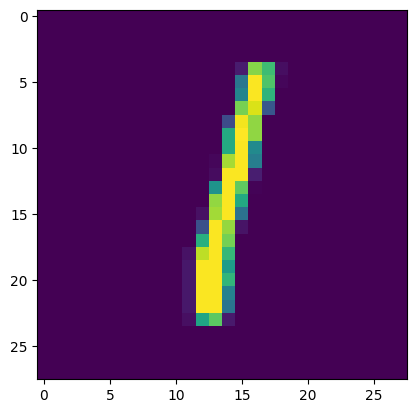

In [34]:
random_image = random.choice(x_train) #Picks a random image from the x_train dataset.
plt.imshow(random_image) #Displays the selected image using matplotlib.

In [91]:
x_train=x_train/255

In [92]:
x_test=x_test/255

 #### Image reshaping for CNN input:

In [93]:
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

#### One-hot encoding of labels:

In [94]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

### Visualize Sample Digits

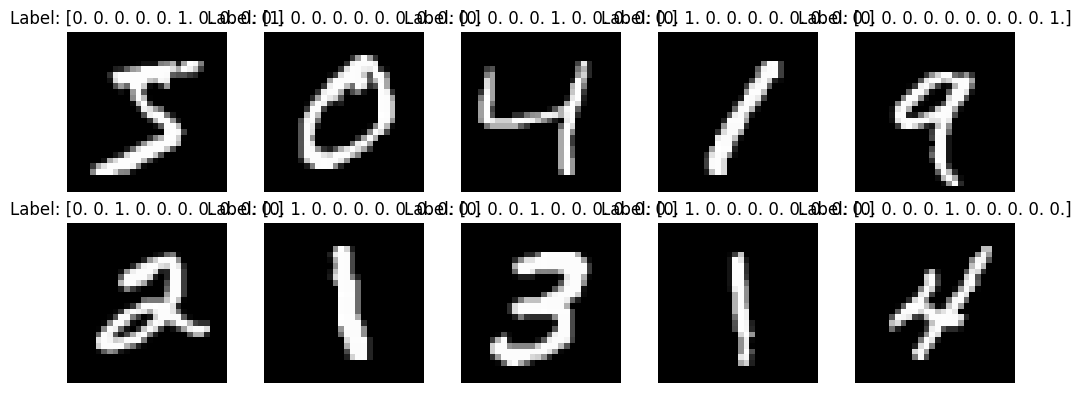

In [95]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Some Distributions:-



 ### Class Label Distribution
 ##### Shows how many samples there are for each digit class (0–9)

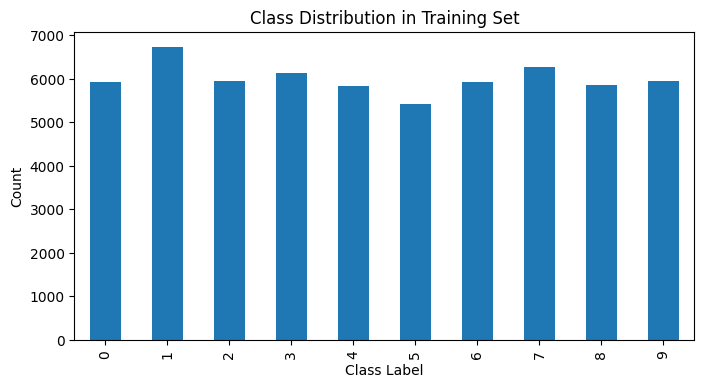

In [96]:
# Convert one-hot encoded labels to class labels
class_labels = np.argmax(y_train, axis=1)

# Create Pandas Series and plot class distribution
class_counts = pd.Series(class_labels).value_counts().sort_index()

plt.figure(figsize=(8, 4))
class_counts.plot(kind='bar')
plt.title('Class Distribution in Training Set')
plt.xlabel('Class Label')
plt.ylabel('Count')
plt.show()

### Pixel Intensity Distribution (Across All Images)
##### Shows distribution of normalized pixel brightness values (0 to 1).

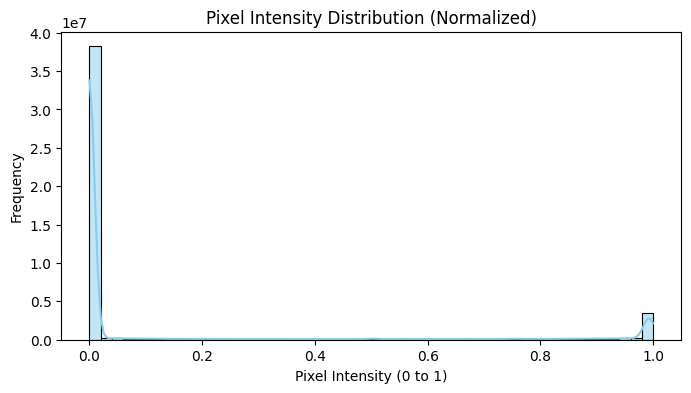

Pixel Intensity Summary:
Min: 0.0000
Max: 1.0000
Mean: 0.1307
Std: 0.3081
Median: 0.0000


In [97]:
# Flatten all images to get a 1D array of pixel values
pixel_values = x_train.flatten()

# Histogram of pixel intensities
plt.figure(figsize=(8,4))
sns.histplot(pixel_values, bins=50, kde=True, color='skyblue')
plt.title("Pixel Intensity Distribution (Normalized)")
plt.xlabel("Pixel Intensity (0 to 1)")
plt.ylabel("Frequency")
plt.show()

# Summary statistics
print("Pixel Intensity Summary:")
print(f"Min: {pixel_values.min():.4f}")
print(f"Max: {pixel_values.max():.4f}")
print(f"Mean: {pixel_values.mean():.4f}")
print(f"Std: {pixel_values.std():.4f}")
print(f"Median: {np.median(pixel_values):.4f}")


### Mean, Std Deviation, and Variance Per Class
##### Computes the average, spread, and variability of pixel values for each digit class.

In [98]:
import numpy as np
import pandas as pd

# Convert one-hot encoded labels to label indices
y_train_labels = np.argmax(y_train, axis=1)

# Dictionary to hold statistics for each digit class
digit_stats = {}

# Iterate over digits 0-9
for digit in range(10):
    # Index x_train using the label indices
    digit_images = x_train[y_train_labels == digit].reshape(-1, 28 * 28)

    # Compute statistics: mean, std, and variance
    digit_stats[digit] = {
        "mean": np.mean(digit_images),
        "std": np.std(digit_images),
        "var": np.var(digit_images)
    }

# Convert dictionary to DataFrame for easier display
digit_stats_df = pd.DataFrame(digit_stats).T

# Print the statistics
print("Mean, Std, and Variance for each digit class:")
print(digit_stats_df.round(4))


Mean, Std, and Variance for each digit class:
     mean     std     var
0  0.1734  0.3477  0.1209
1  0.0760  0.2443  0.0597
2  0.1490  0.3259  0.1062
3  0.1415  0.3179  0.1011
4  0.1214  0.2975  0.0885
5  0.1287  0.3036  0.0922
6  0.1373  0.3149  0.0992
7  0.1145  0.2917  0.0851
8  0.1502  0.3253  0.1058
9  0.1226  0.2986  0.0892


### Mean Image Per Digit Class
##### Visualizes an "average" digit image per class, useful to understand how a typical digit looks.

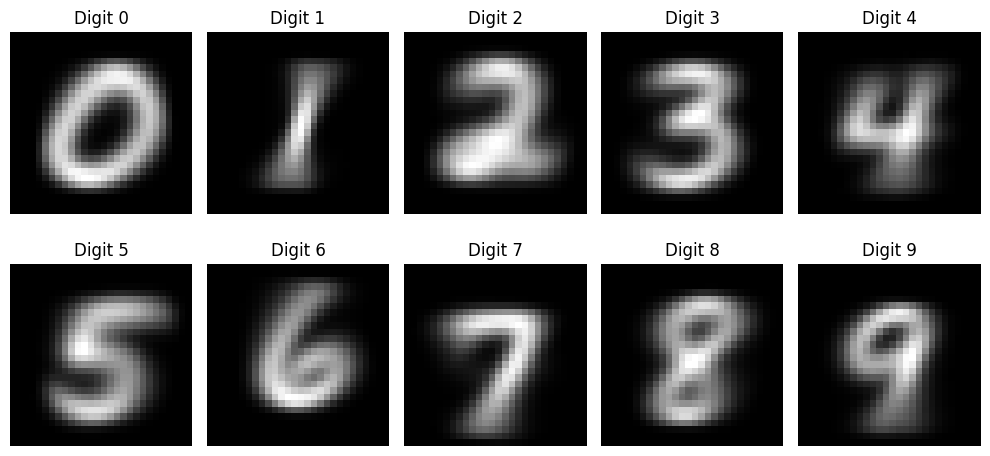

In [99]:
y_train_labels = np.argmax(y_train, axis=1)
x_train[y_train_labels == digit]

import numpy as np
import matplotlib.pyplot as plt

# Convert one-hot to label indices
y_train_labels = np.argmax(y_train, axis=1)

# Plot average images for digits 0–9
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for digit in range(10):
    mean_image = x_train[y_train_labels == digit].mean(axis=0)
    ax = axes[digit // 5, digit % 5]
    ax.imshow(mean_image, cmap='gray')
    ax.set_title(f"Digit {digit}")
    ax.axis('off')

plt.tight_layout()
plt.show()


### Boxplot of Pixel Intensities
##### Shows spread and outliers of sampled pixel values.




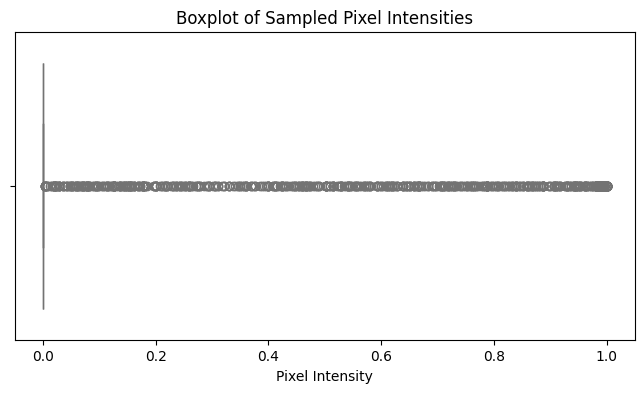

In [101]:
# Sample 5000 pixels for performance
sample_pixels = np.random.choice(pixel_values, size=5000, replace=False)

plt.figure(figsize=(8, 4))
sns.boxplot(x=sample_pixels, color='lightgreen')
plt.title("Boxplot of Sampled Pixel Intensities")
plt.xlabel("Pixel Intensity")
plt.show()


### Class-wise Pixel Mean Distribution

<ipython-input-102-76cb750c8f8c>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(range(10)), y=means_per_digit, palette="cubehelix")


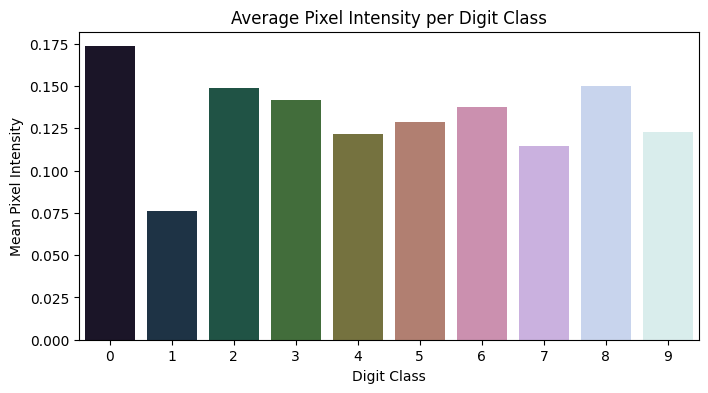

In [102]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Convert one-hot encoded labels to label indices
y_train_labels = np.argmax(y_train, axis=1)

# Compute mean pixel intensity for each digit class
means_per_digit = [x_train[y_train_labels == i].mean() for i in range(10)]

# Plotting
plt.figure(figsize=(8, 4))
sns.barplot(x=list(range(10)), y=means_per_digit, palette="cubehelix")
plt.title("Average Pixel Intensity per Digit Class")
plt.xlabel("Digit Class")
plt.ylabel("Mean Pixel Intensity")
plt.show()

### Lognormal Distribution Fit (Pixel Intensities)
#### Fits a lognormal distribution to pixel values and evaluates the fit.

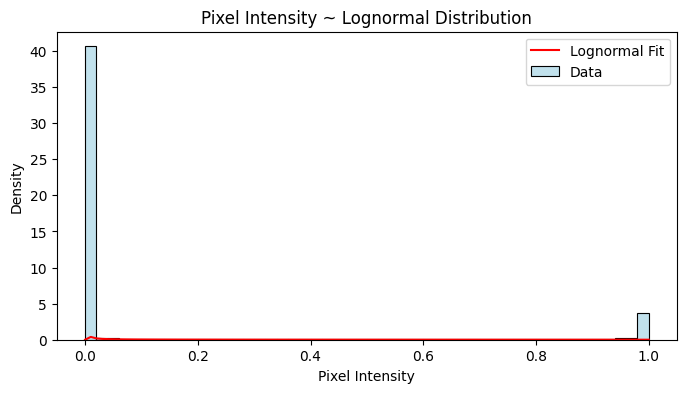

K-S Test: statistic=0.8088, p-value=0.0000


In [103]:
import scipy.stats as stats

from scipy import stats

shape, loc, scale = stats.lognorm.fit(pixel_values + 1e-5)

plt.figure(figsize=(8,4))
sns.histplot(pixel_values, bins=50, stat='density', color='lightblue', label='Data')
x = np.linspace(pixel_values.min(), pixel_values.max(), 100)
pdf = stats.lognorm.pdf(x, shape, loc, scale)
plt.plot(x, pdf, 'r-', label='Lognormal Fit')
plt.title("Pixel Intensity ~ Lognormal Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Density")
plt.legend()
plt.show()

ks_stat, ks_p = stats.kstest(pixel_values, 'lognorm', args=(shape, loc, scale))
print(f"K-S Test: statistic={ks_stat:.4f}, p-value={ks_p:.4f}")



### Binomial-like Distribution: Non-zero Pixels
##### Counts non-zero pixels per image, like a binomial trial (on/off pixels).

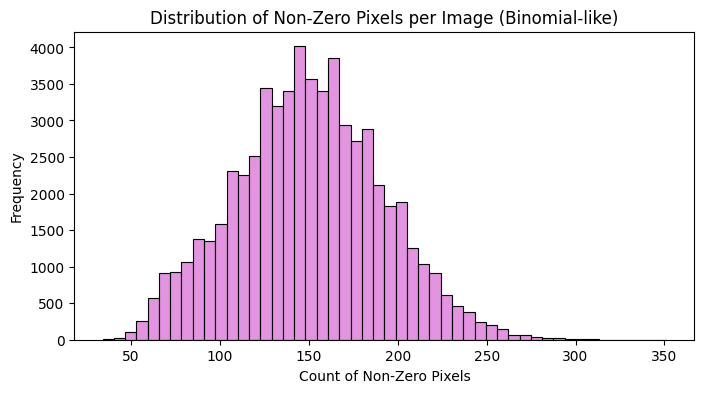

In [104]:
import scipy.stats as stats
# Count non-zero pixels per image
non_zero_counts = np.count_nonzero(x_train > 0, axis=(1,2,3))

# Plot histogram
plt.figure(figsize=(8,4))
sns.histplot(non_zero_counts, bins=50, color='orchid')
plt.title("Distribution of Non-Zero Pixels per Image (Binomial-like)")
plt.xlabel("Count of Non-Zero Pixels")
plt.ylabel("Frequency")
plt.show()

### Multinomial Distribution (Simulated Digit Class Frequencies)
#### Simulates a multinomial distribution using observed digit probabilities.

Empirical Class Probabilities:
0    0.0987
1    0.1124
2    0.0993
3    0.1022
4    0.0974
5    0.0904
6    0.0986
7    0.1044
8    0.0975
9    0.0992
Name: count, dtype: float64


<ipython-input-105-0edc0a8b0313>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(range(10)), y=samples, palette="Spectral")


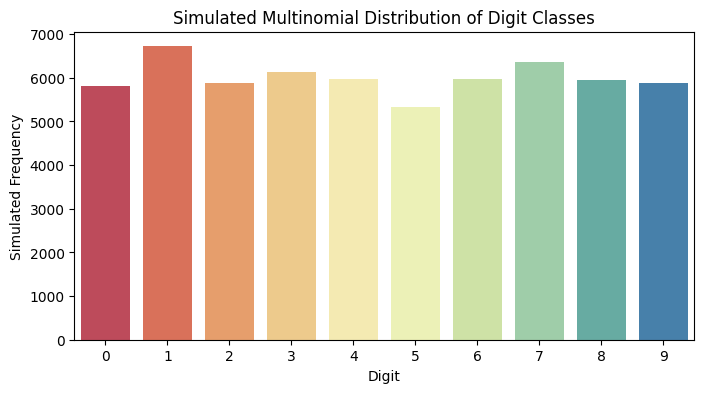

In [105]:
# Frequency of each class
digit_probs = class_counts / class_counts.sum()

print("Empirical Class Probabilities:")
print(digit_probs.round(4))

# Simulate a multinomial distribution
samples = np.random.multinomial(n=60000, pvals=digit_probs)

plt.figure(figsize=(8,4))
sns.barplot(x=list(range(10)), y=samples, palette="Spectral")
plt.title("Simulated Multinomial Distribution of Digit Classes")
plt.xlabel("Digit")
plt.ylabel("Simulated Frequency")
plt.show()

### Hypothesis Test: Are Digits Uniformly Distributed?
#### Uses a Chi-Square test to check if digits occur with equal frequency.

In [106]:
from scipy.stats import chisquare

# Expected uniform distribution
expected = np.full_like(class_counts.values, fill_value=len(y_train)/10)

chi_stat, p_val = chisquare(class_counts.values, f_exp=expected)

print(f"Chi-square test for uniform digit distribution:")
print(f"Chi-square statistic: {chi_stat:.4f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("Result: Reject null hypothesis → digits are not uniformly distributed.")
else:
    print("Result: Fail to reject null hypothesis → digits may be uniformly distributed.")


Chi-square test for uniform digit distribution:
Chi-square statistic: 172.8957
P-value: 0.0000
Result: Reject null hypothesis → digits are not uniformly distributed.


## Summary of Distributions


| Test/Dist.        | Insight |
|-------------------|---------|
| **Lognormal**     | Pixel values follow right-skewed distribution |
| **Binomial**      | Non-zero pixel counts can be modeled as binary trials |
| **Multinomial**   | Digit labels fit multinomial sampling |
| **Chi-Square**    | Test whether all digit classes are evenly represented |

# Building the CNN

In [107]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D,MaxPooling2D,MaxPool2D,Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import SGD

#### Conv2D Layer (1st):
-84 filters of size 3x3

-ReLU activation

-he_uniform for weight initialization

-Input: 28x28 grayscale image

In [108]:
model=Sequential()
model.add(Conv2D(84, (3, 3), input_shape=(28, 28, 1), activation='relu', kernel_initializer='he_uniform'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### MaxPooling Layer (1st):
-Reduces spatial size using 3x3 pooling

-Helps extract dominant features and reduces computation

In [109]:
model.add(MaxPool2D(pool_size=(3,3)))

#### Conv2D Layer (2nd):
-32 filters of size 4x4

-ReLU activation
-⚠️ Note: input_shape=(32,32,3) here is not needed since input shape is already defined earlier.



In [110]:
model.add(Conv2D(filters=32,kernel_size=(4,4),input_shape=(32,32,3),activation='relu',))

#### MaxPooling Layer (2nd):
-Further reduces feature map size

In [111]:
model.add(MaxPool2D(pool_size=(2,2)))

#### Flatten Layer:
-Converts 2D feature maps into a 1D vector for Dense layers

In [112]:
model.add(Flatten())

#### Dense Layer (Hidden):
-Fully connected layer with 256 neurons and ReLU

In [113]:
model.add(Dense(256,activation='relu'))

#### Dense Layer (Output):
-10 output neurons (for digits 0–9)

-Softmax for multi-class classification

In [114]:
model.add(Dense(10, activation='softmax'))

#### Optimizer:
-Stochastic Gradient Descent with momentum to improve convergence speed

In [115]:
opt = SGD(learning_rate=0.01, momentum=0.9)

# Compile the model CNN
- optimizer=opt: Uses the SGD optimizer you defined earlier.

- loss='categorical_crossentropy':Used for multi-class classification when labels are one-hot encoded.

- metrics=['mae', 'accuracy']:

  -accuracy: Measures how often predictions match labels.

  -mae (Mean Absolute Error): Not commonly used for classification, more for regression — optional here.

In [116]:
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['mae', 'accuracy'])

# Model Summary

In [117]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 84)     │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 84)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 5, 5, 32)       │        43,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,474 (310.45 KB)

 Trainable params: 79,474 (310.45 KB)

 Non-trainable params: 0 (0.00 B)


- tensorflow: This is the deep learning framework by Google.

- keras: High-level API inside TensorFlow for building and training neural networks.

- callbacks: A module in Keras that contains classes that can be used at specific stages during training.

- EarlyStopping: A specific callback class that stops training based on a condition you define.

In [118]:
from tensorflow.keras.callbacks import EarlyStopping

-EarlyStopping: A Keras callback that stops training early if performance stops improving.

-monitor='val_loss': Watches the validation loss during training.

-patience=3: If the validation loss doesn’t improve for 3 consecutive epochs, training stops.

In [119]:
early_stop=EarlyStopping(monitor='val_loss',patience=3)

-history: Stores training details (loss, accuracy, etc.) for later plotting or evaluation.

-x_train, y_train: Training images and labels.

-epochs=15: Maximum of 15 training rounds (unless early stopping kicks in).

-validation_data=(x_test, y_test): Checks performance on test data after each epoch.






In [ ]:
history = model.fit(x_train, y_train, epochs=15, validation_data=(x_test, y_test), callbacks=[early_stop])

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 36ms/step - accuracy: 0.8831 - loss: 0.3576 - mae: 0.0324 - val_accuracy: 0.9801 - val_loss: 0.0657 - val_mae: 0.0064
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 87s 38ms/step - accuracy: 0.9791 - loss: 0.0677 - mae: 0.0067 - val_accuracy: 0.9834 - val_loss: 0.0551 - val_mae: 0.0056
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 73s 34ms/step - accuracy: 0.9861 - loss: 0.0448 - mae: 0.0046 - val_accuracy: 0.9858 - val_loss: 0.0443 - val_mae: 0.0042
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 60s 32ms/step - accuracy: 0.9903 - loss: 0.0335 - mae: 0.0035 - val_accuracy: 0.9855 - val_loss: 0.0477 - val_mae: 0.0040
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 87s 35ms/step - accuracy: 0.9915 - loss: 0.0269 - mae: 0.0029 - val_accuracy: 0.9869 - val_loss: 0.0412 - val_mae: 0.0036
Epoch 6/15
  57/1875 ━━━━━━━━━━━━━━━━━━━━ 1:07 37ms/step - accuracy: 0.9967 - loss: 0.0171 - mae: 0.0022

-model.predict(x_test): Returns the model’s probability predictions for each class (shape: [num_samples, 10]).

-np.argmax(..., 1): Picks the index of the highest probability (i.e., the predicted class) for each sample across axis 1.

In [121]:
predictions=np.argmax(model.predict(x_test),1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


In [122]:
predictions

array([7, 2, 1, ..., 4, 5, 6])

-np.argmax(..., axis=1) finds the index of the 1 in each row → gives you the original digit label (0–9).

In [123]:
y_test=np.argmax(y_test, axis=1)

-classification_report: Provides detailed metrics like precision, recall, F1-score for each class, along with overall accuracy.

-confusion_matrix: Shows a matrix of true vs predicted labels, indicating the number of correct and incorrect predictions for each class.

In [124]:
from sklearn.metrics import classification_report,confusion_matrix

In [125]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.98      0.99      0.99      1032
           3       0.97      1.00      0.98      1010
           4       0.98      0.99      0.99       982
           5       1.00      0.96      0.98       892
           6       0.99      0.98      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



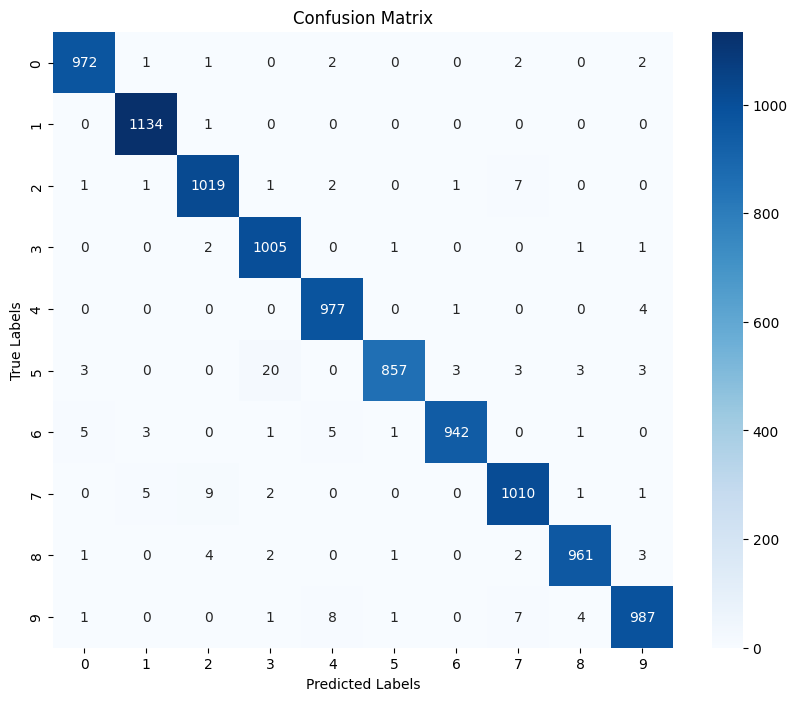

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


# Generate confusion matrix
cm = confusion_matrix(y_test, predictions)

# Create heatmap
plt.figure(figsize=(10, 8))  # Adjust figure size if needed
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

#### Accuracy and Loss:

- acc, val_acc, loss, and val_loss are extracted from the history object, which contains training logs.

  -acc: Training accuracy for each epoch.

  -val_acc: Validation accuracy for each epoch.

  -loss: Training loss for each epoch.

  -val_loss: Validation loss for each epoch.

#### Plotting:

  -The first plot shows Training vs. Validation Accuracy.

  -The second plot shows Training vs. Validation Loss.

  -The use of blue ('b') and red ('r') colors helps differentiate training and validation curves.

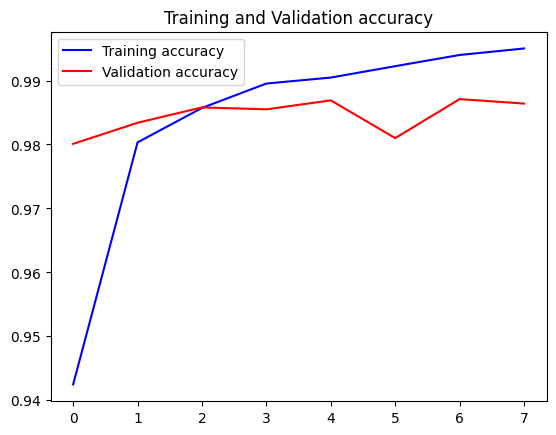

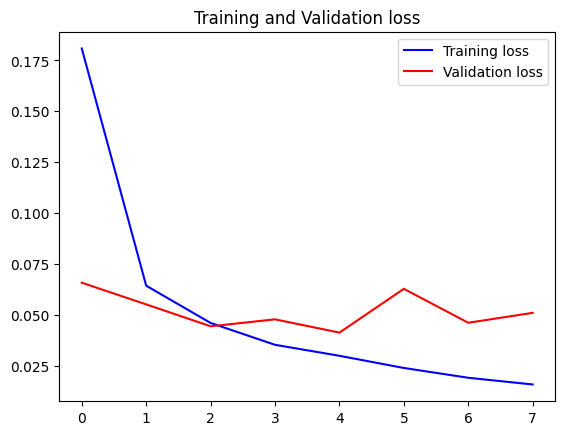

In [127]:

import matplotlib.pyplot as plt

# Assuming 'history' object contains the training history from model.fit
# history = model.fit(...)

# Access training and validation accuracy and loss
# the history variable was assigned in cell 18
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

# Plot training and validation accuracy
plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and Validation accuracy')
plt.legend()

plt.figure()

# Plot training and validation loss
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation loss')
plt.legend()

plt.show()

# Save the Model

In [128]:
model.save("recognizer.keras")

# Image Processing
- Decodes base64 image data sent from the frontend (JavaScript canvas).

- Converts to grayscale and resizes to 28x28 pixels (required by the model).

- Inverts the image if the background is white (common for canvas images).

- Normalizes pixel values to the range [0, 1] and reshapes it for the model input.

- Predicts the digit using the model and outputs the predicted class and confidence.

In [133]:
from IPython.display import display
import numpy as np
import cv2
from tensorflow.keras.models import load_model

model = load_model('recognizer.keras')  # Replace with your model path

def predict_from_js(img_data_url):
    from base64 import b64decode
    import PIL.Image
    import io

    # Decode image from JS canvas
    header, encoded = img_data_url.split(",", 1)
    decoded = b64decode(encoded)
    img = PIL.Image.open(io.BytesIO(decoded)).convert("L")  # Convert to grayscale

    # Resize to 28x28 (match model input)
    img = img.resize((28, 28))

    # Convert to numpy array
    img_np = np.array(img)

    # Invert image if background is white (common for canvas)
    img_np = 255 - img_np

    # Normalize
    img_np = img_np.astype("float32") / 255.0

    # Reshape to match model input (batch_size, height, width, channels)
    img_np = img_np.reshape(1, 28, 28, 1)

    # Predict
    pred = model.predict(img_np)[0]
    pred_class = np.argmax(pred)
    confidence = pred[pred_class]

    print(f"\n✅ Predicted Digit: {pred_class} | Confidence: {confidence:.2f}")


from google.colab import output
output.register_callback('notebook.get_image', predict_from_js)


In [136]:
from IPython.display import HTML, display
from google.colab.output import eval_js
from base64 import b64decode
import PIL.Image
import io

canvas_html = """
<canvas id="canvas" width="280" height="280" style="border:1px solid black; touch-action:none;"></canvas><br>
<button onclick="clearCanvas()">Clear</button>
<button onclick="getImage()">Predict</button>
<script>
var canvas = document.getElementById('canvas');
var ctx = canvas.getContext('2d');
ctx.fillStyle = "white";
ctx.fillRect(0, 0, canvas.width, canvas.height);


canvas.onmousedown = function(e) {
    ctx.moveTo(e.offsetX, e.offsetY);
    canvas.onmousemove = function(e) {
        ctx.lineTo(e.offsetX, e.offsetY);
        ctx.stroke();
    }
}
canvas.onmouseup = function(e) {
    canvas.onmousemove = null;
}


function clearCanvas() {
    ctx.fillStyle = "white";
    ctx.fillRect(0, 0, canvas.width, canvas.height);
}

function getImage() {
    var imgData = canvas.toDataURL('image/png');
    google.colab.kernel.invokeFunction('notebook.get_image', [imgData], {});
}
</script>
"""

display(HTML(canvas_html))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

✅ Predicted Digit: 1 | Confidence: 0.26
